# Modèle 2 — Repli GPS

Évalue et sauvegarde les modèles de repli pour les écarts de signal GPS :

| modèle | rôle | sortie |
|--------|------|--------|
| **Interpolation linéaire** | comble les écarts fermés | stateless, pas de fichier |
| **Filtre de Kalman** | lisse la trace + quantifie l'incertitude | stateless |
| **Correction LSTM** | corrige les résidus Kalman | `fallback_lstm.pt` |

Modifiez le bloc **Config** pour changer de bus/jour/ligne.

In [14]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parents[1]))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display

from src.data.db import get_db
from src.data import foundation as fdn
from src.data import fallback as fb

print('imports OK')

imports OK


In [15]:
# Config
LINE    = '209'
SOCIETE = 'S.R.T.K'
BUS     = 6030
DAY     = 'd20260615'   

# Évaluation sur écarts synthétiques
MASK_MIN  = 3           # minutes à masquer par écart synthétique
N_SAMPLES = 200         # nombre d'écarts synthétiques

# LSTM correction
LSTM_WINDOW  = 10       # pings d'historique à utiliser
LSTM_HIDDEN  = 32
LSTM_EPOCHS  = 20

# Chemins
ROOT       = Path.cwd().parents[1]
MODELS_DIR = ROOT / 'models' / 'fallback'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f'ligne {LINE} | bus {BUS} | jour {DAY[1:]}')

ligne 209 | bus 6030 | jour 20260615


In [16]:
# Charger la trace GPS du bus pour la journée
db_winicari = get_db('winicari')
db_gps      = get_db('Historique_pos')
CFG         = fdn.Config()
USABLE      = fdn.build_usable_lines(db_winicari, CFG)
stops       = USABLE[(LINE, SOCIETE)]

raw        = fdn.load_pings(db_gps, DAY, LINE, BUS)
g          = fdn.clean_pings(raw, CFG)
g, route_len = fdn.project_to_route(g, stops, CFG)

print(f'pings : {len(g)} | itinéraire : {route_len/1000:.0f} km | '
      f'écarts de signal : {g["signal_gap"].sum()}')

pings : 3582 | itinéraire : 192 km | écarts de signal : 4


,gap_min,s_start_km,s_end_km,dist_covered_km,speed_before_kph
0,12.8,33.2,43.2,10.0,92.9
1,31.6,71.3,104.2,33.0,99.7
2,60.1,115.8,168.1,52.3,18.0
3,13.2,110.8,98.4,12.4,89.2


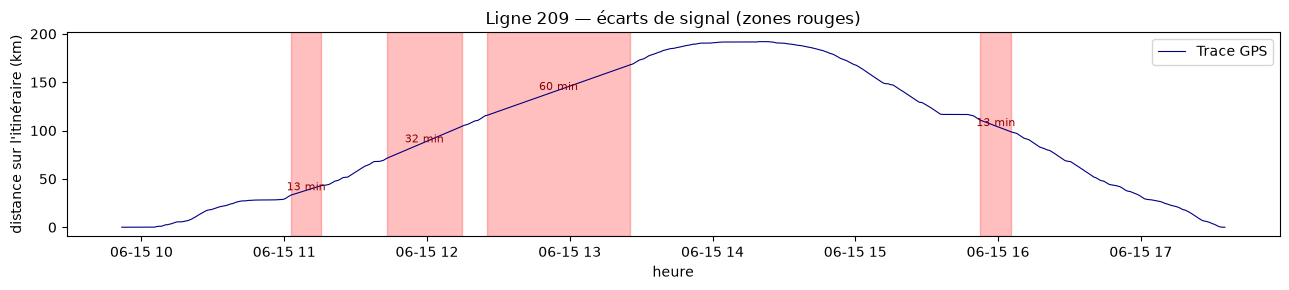

In [17]:
# Tableau des écarts + visualisation
gaps = fb.gap_table(g)
display(gaps[['gap_min','s_start_km','s_end_km','dist_covered_km','speed_before_kph']])

plt.figure(figsize=(13, 3))
plt.plot(g['t'], g['s']/1000, lw=0.8, color='navy', label='Trace GPS')
for _, row in gaps.iterrows():
    plt.axvspan(row['t_start'], row['t_end'], alpha=0.25, color='red')
    mid = row['t_start'] + (row['t_end'] - row['t_start'])/2
    plt.text(mid, (row['s_start_km']+row['s_end_km'])/2,
             f"{row['gap_min']:.0f} min", ha='center', fontsize=8, color='darkred')
plt.ylabel("distance sur l'itinéraire (km)"); plt.xlabel('heure')
plt.title(f'Ligne {LINE} — écarts de signal (zones rouges)')
plt.legend(); plt.tight_layout(); plt.show()

In [18]:
# Évaluer l'interpolation linéaire sur écarts synthétiques
trips = fdn.segment_trips(g, route_len, CFG)
g_trip = g[(g['t'] >= trips.iloc[0]['start']) &
           (g['t'] <= trips.iloc[0]['end'])].reset_index(drop=True)

eval_df = fb.eval_fallback(g_trip, stops, mask_min=MASK_MIN, n_samples=N_SAMPLES)

print(f'écarts synthétiques évalués : {len(eval_df)}')
print('\nErreur de position (mètres) :')
print(eval_df[['err_interp_m','err_dr_m']].describe().round(0).to_string())
print(f'\nMédiane  interp : {eval_df["err_interp_m"].median():.0f} m  |  '
      f'calcul à l\'estime : {eval_df["err_dr_m"].median():.0f} m')
print(f'90e pct  interp : {eval_df["err_interp_m"].quantile(0.9):.0f} m  |  '
      f'calcul à l\'estime : {eval_df["err_dr_m"].quantile(0.9):.0f} m')

écarts synthétiques évalués : 197

Erreur de position (mètres) :
       err_interp_m  err_dr_m
count         197.0     197.0
mean          529.0     674.0
std           560.0     595.0
min             9.0       1.0
25%           173.0     285.0
50%           407.0     556.0
75%           605.0     800.0
max          2807.0    2959.0

Médiane  interp : 407 m  |  calcul à l'estime : 556 m
90e pct  interp : 1046 m  |  calcul à l'estime : 1375 m


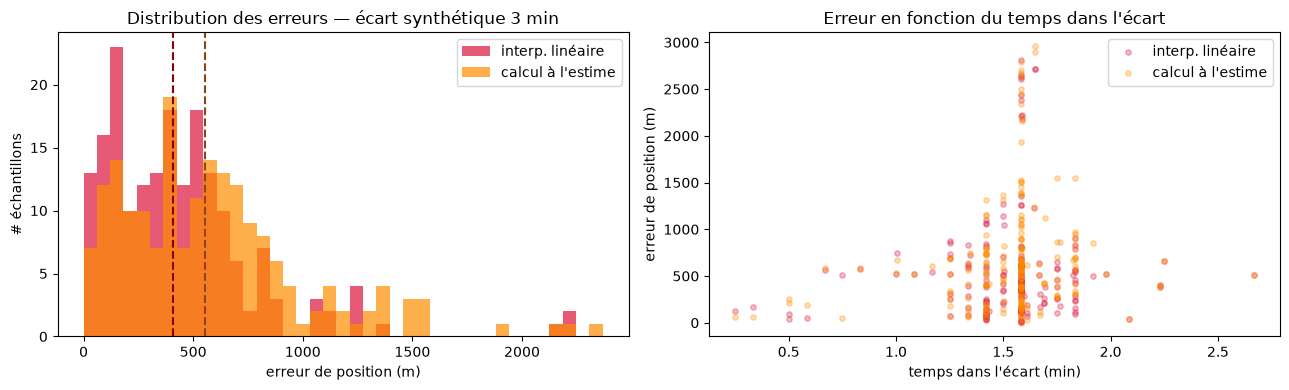

In [19]:
# Visualiser la distribution des erreurs
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

cap = eval_df[['err_interp_m','err_dr_m']].values.max() * 0.8
bins = np.linspace(0, cap, 40)
ax[0].hist(eval_df['err_interp_m'], bins=bins, alpha=0.7, color='crimson',   label='interp. linéaire')
ax[0].hist(eval_df['err_dr_m'],     bins=bins, alpha=0.7, color='darkorange', label="calcul à l'estime")
ax[0].axvline(eval_df['err_interp_m'].median(), color='darkred',     ls='--', lw=1.5)
ax[0].axvline(eval_df['err_dr_m'].median(),     color='saddlebrown', ls='--', lw=1.5)
ax[0].set_xlabel('erreur de position (m)'); ax[0].set_ylabel('# échantillons')
ax[0].set_title(f'Distribution des erreurs — écart synthétique {MASK_MIN} min')
ax[0].legend()

ax[1].scatter(eval_df['dt_into_gap_s']/60, eval_df['err_interp_m'],
              alpha=0.3, s=15, color='crimson',   label='interp. linéaire')
ax[1].scatter(eval_df['dt_into_gap_s']/60, eval_df['err_dr_m'],
              alpha=0.3, s=15, color='darkorange', label="calcul à l'estime")
ax[1].set_xlabel("temps dans l'écart (min)"); ax[1].set_ylabel('erreur de position (m)')
ax[1].set_title("Erreur en fonction du temps dans l'écart")
ax[1].legend()
plt.tight_layout(); plt.show()

In [20]:
# Appliquer le filtre de Kalman sur la trace complète
g_kf = fb.kalman_filter_track(g, route_len)
print(f'colonnes Kalman ajoutées : ks (distance lissée), kv (vitesse), kp (incertitude)')
print(g_kf[['t','s','ks','kp']].describe().round(1).to_string())

colonnes Kalman ajoutées : ks (distance lissée), kv (vitesse), kp (incertitude)
                                   t         s        ks       kp
count                           3582    3582.0    3582.0   3582.0
mean   2026-06-15 14:07:22.399582976   92405.4   92404.6     98.3
min       2026-06-15 09:51:43.431000       0.0       0.0     57.3
25%    2026-06-15 11:34:34.039000064   28120.3   28119.4     57.3
50%    2026-06-15 14:37:49.195000064   74393.4   74392.4     57.3
75%    2026-06-15 16:16:36.276000256  169611.4  169582.5     57.3
max       2026-06-15 17:35:18.426000  192015.9  192015.9  89279.3
std                              NaN   68155.6   68152.6   1611.2


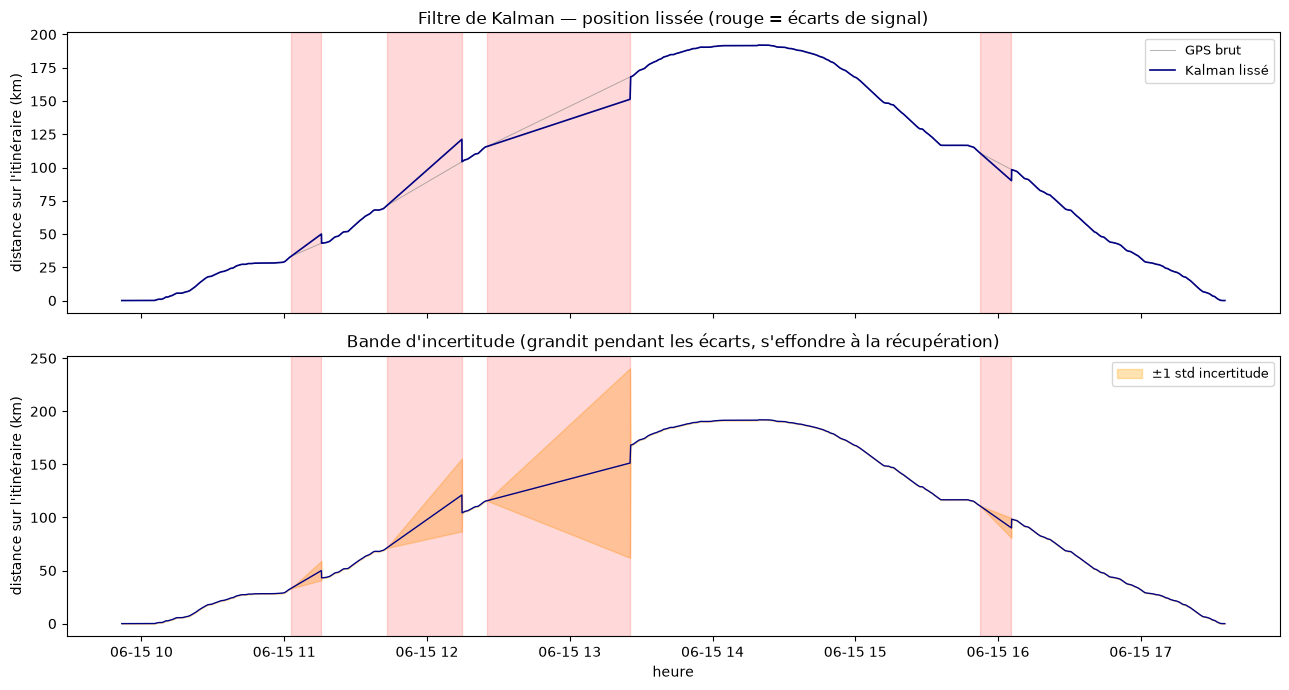

In [21]:
# Visualiser le lissage Kalman + bande d'incertitude
fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax[0].plot(g_kf['t'], g_kf['s']/1000,  lw=0.7, color='grey',  alpha=0.6, label='GPS brut')
ax[0].plot(g_kf['t'], g_kf['ks']/1000, lw=1.2, color='navy',             label='Kalman lissé')
for _, row in gaps.iterrows():
    ax[0].axvspan(row['t_start'], row['t_end'], alpha=0.15, color='red')
ax[0].set_ylabel("distance sur l'itinéraire (km)")
ax[0].set_title('Filtre de Kalman — position lissée (rouge = écarts de signal)')
ax[0].legend(fontsize=9)

ax[1].fill_between(g_kf['t'],
                   (g_kf['ks']-g_kf['kp'])/1000,
                   (g_kf['ks']+g_kf['kp'])/1000,
                   alpha=0.3, color='orange', label='±1 std incertitude')
ax[1].plot(g_kf['t'], g_kf['ks']/1000, lw=1, color='navy')
for _, row in gaps.iterrows():
    ax[1].axvspan(row['t_start'], row['t_end'], alpha=0.15, color='red')
ax[1].set_ylabel("distance sur l'itinéraire (km)"); ax[1].set_xlabel('heure')
ax[1].set_title("Bande d'incertitude (grandit pendant les écarts, s'effondre à la récupération)")
ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

In [22]:
# Évaluer Kalman vs interpolation linéaire sur mêmes écarts synthétiques
g_trip_kf = fb.kalman_filter_track(g_trip, route_len)
rng    = np.random.default_rng(42)
t_unix = (pd.to_datetime(g_trip['t']).astype(np.int64) // 10**9).values
candidates = np.where(~g_trip['signal_gap'].values)[0]
candidates = candidates[candidates < len(g_trip) - 5]
mask_s = MASK_MIN * 60

results = []
for _ in range(N_SAMPLES):
    i0 = int(rng.choice(candidates))
    future = np.where(t_unix > t_unix[i0] + mask_s)[0]
    if not len(future): continue
    i1 = int(future[0])
    inside = g_trip.iloc[i0+1:i1]
    if not len(inside): continue
    mid = inside.iloc[len(inside)//2]
    tq = pd.Timestamp(mid['t']); true_lat, true_lon = float(mid['lat']), float(mid['lon'])
    b4, af = g_trip.iloc[i0], g_trip.iloc[i1]
    li, lo, _ = fb.interp_position(tq, pd.Timestamp(b4['t']), float(b4['s']),
                                    pd.Timestamp(af['t']), float(af['s']), stops)
    kr = fb.kalman_fallback(g_trip_kf, tq, stops)
    results.append({'err_interp_m': fb.haversine_m(true_lat, true_lon, li, lo),
                    'err_kalman_m': fb.haversine_m(true_lat, true_lon, kr['lat'], kr['lon']) if kr else np.nan})

res = pd.DataFrame(results).dropna()
print(f'écarts évalués : {len(res)}')
print(f'Interp. linéaire   médiane={res["err_interp_m"].median():.0f} m  '
      f'90e={res["err_interp_m"].quantile(0.9):.0f} m')
print(f'Kalman             médiane={res["err_kalman_m"].median():.0f} m  '
      f'90e={res["err_kalman_m"].quantile(0.9):.0f} m')

écarts évalués : 197
Interp. linéaire   médiane=407 m  90e=1046 m
Kalman             médiane=115 m  90e=667 m


In [23]:
# Entraîner la correction LSTM sur les résidus Kalman
lstm_corr, corr_mean, corr_std = fb.train_lstm_correction(
    g_trip_kf, window=LSTM_WINDOW)

if lstm_corr:
    print(f'Correction LSTM entraînée ✓  (window={LSTM_WINDOW}, hidden={LSTM_HIDDEN}, epochs={LSTM_EPOCHS})')
else:
    print('Pas assez de données non-écart pour entraîner la correction LSTM sur ce trajet.')

Correction LSTM entraînée ✓  (window=10, hidden=32, epochs=20)


Testing window in [5, 10, 15, 20, 30] ...

  window= 5  →  median position error = 43822 m  (n_samples=197)
  window=10  →  median position error = 43823 m  (n_samples=197)
  window=15  →  median position error = 43823 m  (n_samples=197)
  window=20  →  median position error = 43823 m  (n_samples=197)
  window=30  →  median position error = 43823 m  (n_samples=197)

Window grid results (median error ↓ = better):


,window,median_err_m
0,5,43822.430596
1,10,43822.797440
2,15,43823.072287
3,20,43823.328474
4,30,43823.364015



Best window : 5  →  43822 m median error
lstm_corr / corr_mean / corr_std updated ✓


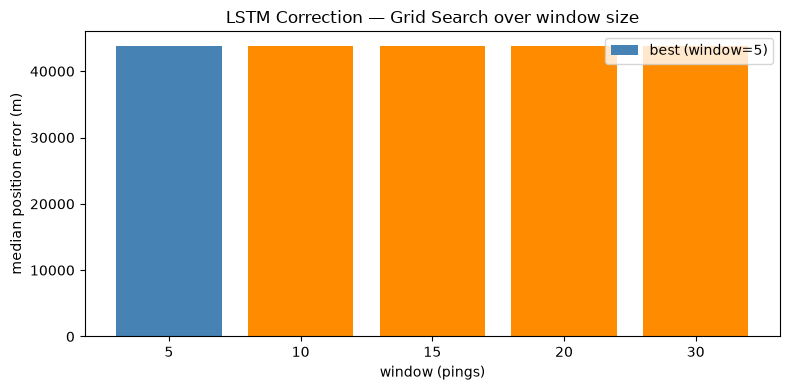

In [ ]:
# Grid Search — Correction LSTM 
window_grid = [5, 10, 15, 20, 30]
fb_results  = []

print(f'Testing window in {window_grid} ...\n')

for window in window_grid:
    m, cm, cs = fb.train_lstm_correction(g_trip_kf, window=window)
    if m is None:
        print(f'  window={window:2d}  →  not enough non-gap pings, skipped')
        continue

    errors_w = []
    rng_gs = np.random.default_rng(99)
    for _ in range(N_SAMPLES):
        i0 = int(rng_gs.choice(candidates))
        future = np.where(t_unix > t_unix[i0] + mask_s)[0]
        if not len(future):
            continue
        i1 = int(future[0])
        inside = g_trip.iloc[i0 + 1:i1]
        if not len(inside):
            continue
        mid = inside.iloc[len(inside) // 2]
        tq = pd.Timestamp(mid['t'])
        true_lat, true_lon = float(mid['lat']), float(mid['lon'])
        kr2 = fb.kalman_lstm_fallback(g_trip_kf, tq, stops, m, cm, cs, window=window)
        if kr2:
            errors_w.append(fb.haversine_m(true_lat, true_lon, kr2['lat'], kr2['lon']))

    med_err = float(np.median(errors_w)) if errors_w else float('nan')
    fb_results.append({'window': window, 'median_err_m': med_err,
                       'model': m, 'mean': cm, 'std': cs})
    print(f'  window={window:2d}  →  median position error = {med_err:.0f} m  '
          f'(n_samples={len(errors_w)})')

fb_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('model', 'mean', 'std')}
                       for r in fb_results])
print('\nWindow grid results (median error ↓ = better):')
display(fb_df.sort_values('median_err_m').reset_index(drop=True))

best_fb_idx = fb_df['median_err_m'].idxmin()
best_fb_row = fb_results[best_fb_idx]
best_win    = int(best_fb_row['window'])
print(f'\nBest window : {best_win}  →  {best_fb_row["median_err_m"]:.0f} m median error')

# Update variables so the save cell writes the best model
lstm_corr  = best_fb_row['model']
corr_mean  = best_fb_row['mean']
corr_std   = best_fb_row['std']
print('lstm_corr / corr_mean / corr_std updated ✓')

# Comparison bar chart
if len(fb_df) > 1:
    fig_gs, ax_gs = plt.subplots(figsize=(8, 4))
    ax_gs.bar(fb_df['window'].astype(str), fb_df['median_err_m'], color='darkorange')
    ax_gs.bar([str(best_win)], [best_fb_row['median_err_m']], color='steelblue',
              label=f'best (window={best_win})')
    ax_gs.set_xlabel('window (pings)'); ax_gs.set_ylabel('median position error (m)')
    ax_gs.set_title('LSTM Correction — Grid Search over window size')
    ax_gs.legend(); plt.tight_layout(); plt.show()

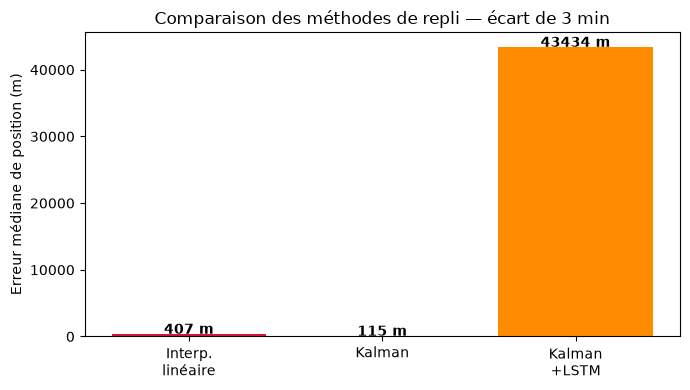

Interp. linéaire : 407 m
Kalman           : 115 m
Kalman + LSTM    : 43434 m


In [25]:
# Comparaison finale : Interp vs Kalman vs Kalman+LSTM
if lstm_corr:
    errors_lstm = []
    for _ in range(N_SAMPLES):
        i0 = int(rng.choice(candidates))
        future = np.where(t_unix > t_unix[i0] + mask_s)[0]
        if not len(future): continue
        i1 = int(future[0])
        inside = g_trip.iloc[i0+1:i1]
        if not len(inside): continue
        mid = inside.iloc[len(inside)//2]
        tq = pd.Timestamp(mid['t']); true_lat, true_lon = float(mid['lat']), float(mid['lon'])
        kr2 = fb.kalman_lstm_fallback(g_trip_kf, tq, stops, lstm_corr, corr_mean, corr_std)
        if kr2:
            errors_lstm.append(fb.haversine_m(true_lat, true_lon, kr2['lat'], kr2['lon']))

    med_lstm = np.median(errors_lstm) if errors_lstm else float('nan')

    labels = ["Interp.\nlinéaire", "Kalman", "Kalman\n+LSTM"]
    medians = [res['err_interp_m'].median(), res['err_kalman_m'].median(), med_lstm]

    plt.figure(figsize=(7, 4))
    bars = plt.bar(labels, medians, color=['crimson','navy','darkorange'])
    for b, v in zip(bars, medians):
        plt.text(b.get_x()+b.get_width()/2, v+5, f'{v:.0f} m', ha='center', fontweight='bold')
    plt.ylabel('Erreur médiane de position (m)')
    plt.title(f'Comparaison des méthodes de repli — écart de {MASK_MIN} min')
    plt.tight_layout(); plt.show()

    print(f'Interp. linéaire : {res["err_interp_m"].median():.0f} m')
    print(f'Kalman           : {res["err_kalman_m"].median():.0f} m')
    print(f'Kalman + LSTM    : {med_lstm:.0f} m')

In [26]:
# Sauvegarder les modèles
if lstm_corr:
    import joblib
    torch.save(lstm_corr.state_dict(), MODELS_DIR / 'fallback_lstm.pt')
    joblib.dump({'mean': corr_mean, 'std': corr_std}, MODELS_DIR / 'fallback_lstm_scaler.pkl')
    print('✓  fallback_lstm.pt')
    print('✓  fallback_lstm_scaler.pkl')
else:
    print('LSTM non entraîné — rien à sauvegarder.')

print(f'\nModèles sauvegardés dans : {MODELS_DIR}')

✓  fallback_lstm.pt
✓  fallback_lstm_scaler.pkl

Modèles sauvegardés dans : c:\Users\deadx\OneDrive\Desktop\winicari\models\fallback
